# Test, Load and Use DDPM and DDIM from Models
# Just for checking...

This notebook shows how to:

1. locate the repo root
2. import `DDPMWrapper` and `DDIMWrapper`
3. load the pretrained CIFAR-10 diffusion checkpoint
4. generate images with DDPM
5. generate images with DDIM
6. visualize and save the outputs

Both wrappers return:
- a `torch.Tensor`
- shape `[N, C, H, W]`
- values in `[-1, 1]`

Both models come from the same pretrained CIFAR-10 diffusion checkpoint:

- **Model source:** `google/ddpm-cifar10-32`
- **Platform:** Hugging Face Diffusers

Important:
- **DDPM** uses the pretrained checkpoint with the **DDPM sampling pipeline**
- **DDIM** uses the **same pretrained checkpoint**, but with the **DDIM sampling pipeline**

In [16]:
from __future__ import annotations

import sys
from pathlib import Path

import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid, save_image

In [17]:
CURRENT = Path.cwd().resolve()
if (CURRENT / "Models").exists():
    REPO_ROOT = CURRENT
elif (CURRENT.parent / "Models").exists():
    REPO_ROOT = CURRENT.parent
else:
    raise RuntimeError("Could not locate repository root.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: C:\Users\aggel\OneDrive\Υπολογιστής\Group07_Improving_Metrics


In [18]:
from Models.pretrained_wrappers import DDPMWrapper, DDIMWrapper

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [20]:
DDPM_CHECKPOINT = REPO_ROOT / "checkpoints" / "DDPM" / "CIFAR10"

print("Checkpoint path:", DDPM_CHECKPOINT)
print("Exists:", DDPM_CHECKPOINT.exists())

Checkpoint path: C:\Users\aggel\OneDrive\Υπολογιστής\Group07_Improving_Metrics\checkpoints\DDPM\CIFAR10
Exists: True


In [21]:
for p in sorted(DDPM_CHECKPOINT.rglob("*")):
    print(p.relative_to(DDPM_CHECKPOINT))

model_index.json
scheduler
scheduler\scheduler_config.json
unet
unet\config.json
unet\diffusion_pytorch_model.safetensors


In [22]:
def show_images(images: torch.Tensor, title: str, nrow: int = 4):
    """
    Display a batch of images returned by the wrappers.

    The wrappers return values in [-1, 1], so we convert them to [0, 1]
    before displaying.
    """
    x = ((images.detach().cpu() + 1.0) / 2.0).clamp(0.0, 1.0)
    grid = make_grid(x, nrow=nrow)

    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title(title)
    plt.axis("off")
    plt.show()

In [23]:
ddpm = DDPMWrapper(str(DDPM_CHECKPOINT))
print(ddpm)

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

In [24]:
ddpm_samples = ddpm.sample(
    n=8,                 # number of images
    device=device,       # cpu or cuda
    seed=42,             # fixed seed for reproducibility
    num_inference_steps=1000,   # standard DDPM sampling
)

print("DDPM output type:", type(ddpm_samples))
print("DDPM output shape:", ddpm_samples.shape)
print("DDPM min/max:", ddpm_samples.min().item(), ddpm_samples.max().item())

  0%|          | 0/1000 [00:00<?, ?it/s]

DDPM output type: <class 'torch.Tensor'>
DDPM output shape: torch.Size([8, 3, 32, 32])
DDPM min/max: -1.0 1.0


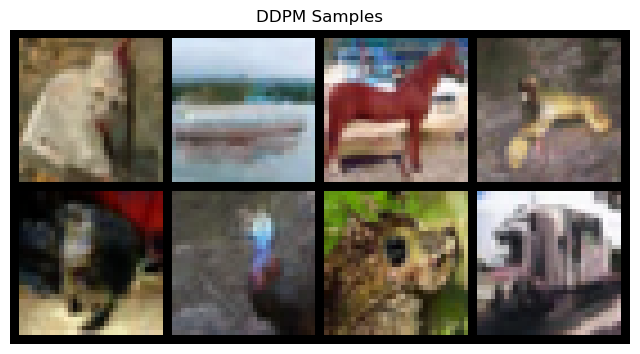

In [25]:
show_images(ddpm_samples, "DDPM Samples", nrow=4)

In [26]:
ddim = DDIMWrapper(str(DDPM_CHECKPOINT))
print(ddim)

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

In [27]:
ddim_samples = ddim.sample(
    n=8,
    device=device,
    seed=42,
    num_inference_steps=50,   # DDIM is usually used with fewer steps
)

print("DDIM output type:", type(ddim_samples))
print("DDIM output shape:", ddim_samples.shape)
print("DDIM min/max:", ddim_samples.min().item(), ddim_samples.max().item())

  0%|          | 0/50 [00:00<?, ?it/s]

DDIM output type: <class 'torch.Tensor'>
DDIM output shape: torch.Size([8, 3, 32, 32])
DDIM min/max: -1.0 0.9828751087188721


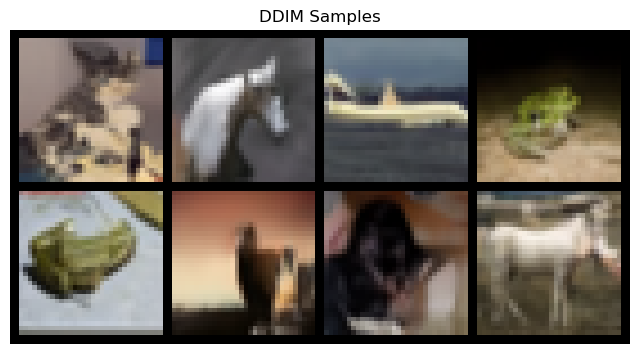

In [28]:
show_images(ddim_samples, "DDIM Samples", nrow=4)

In [29]:
print("DDPM shape:", ddpm_samples.shape)
print("DDIM shape:", ddim_samples.shape)

DDPM shape: torch.Size([8, 3, 32, 32])
DDIM shape: torch.Size([8, 3, 32, 32])


In [30]:
out_dir = REPO_ROOT / "outputs" / "model_tests"
out_dir.mkdir(parents=True, exist_ok=True)

save_image(((ddpm_samples + 1) / 2).clamp(0, 1), out_dir / "ddpm_samples.png", nrow=4)
save_image(((ddim_samples + 1) / 2).clamp(0, 1), out_dir / "ddim_samples.png", nrow=4)

print("Saved to:", out_dir)

Saved to: C:\Users\aggel\OneDrive\Υπολογιστής\Group07_Improving_Metrics\outputs\model_tests


In [31]:
ddpm_a = ddpm.sample(n=4, device=device, seed=123, num_inference_steps=100)
ddpm_b = ddpm.sample(n=4, device=device, seed=123, num_inference_steps=100)

print("DDPM deterministic with same seed:", torch.allclose(ddpm_a, ddpm_b))

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

DDPM deterministic with same seed: True


In [32]:
ddim_a = ddim.sample(n=4, device=device, seed=1, num_inference_steps=50)
ddim_b = ddim.sample(n=4, device=device, seed=2, num_inference_steps=50)

print("Mean absolute difference:", (ddim_a - ddim_b).abs().mean().item())

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Mean absolute difference: 0.43979206681251526
